### 3.2 Avaliação de Métricas — BLEU, COMET e Latência

Nesta seção, avaliamos a qualidade das traduções geradas pelos dois sistemas 
(NeMo Canary v2 e SeamlessM4T v2) utilizando métricas padrão de tradução automática:

- **BLEU**: mede a sobreposição de n-gramas entre a tradução gerada e a referência humana
- **COMET**: métrica neural que avalia qualidade semântica, com maior correlação 
  com julgamento humano do que métricas baseadas em sobreposição lexical

Também analisamos a **latência de inferência** (tempo de processamento por amostra) 
de cada sistema, identificando outliers e discutindo limitações decorrentes do uso 
de hardware distinto entre os dois experimentos (GPU T4 no Google Colab para o 
NeMo Canary, e GPU RTX 3050 6GB local para o SeamlessM4T).

In [10]:
pip install sacrebleu unbabel-comet

Note: you may need to restart the kernel to use updated packages.


In [11]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS"] = "1"

from comet import download_model, load_from_checkpoint

model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(model_path)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\david\.cache\huggingface\hub\models--Unbabel--wmt22-comet-da\snapshots\2760a223ac957f30acfb18c8aa649b01cf1d75f2\checkpoints\model.ckpt`
c:\Users\david\miniconda3\envs\asr-benchmark\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Encoder model frozen.
c:\Users\david\miniconda3\envs\asr-benchmark\lib\site-packages\pytorch_lightning\core\saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [12]:
import pandas as pd

df_canary = pd.read_csv('../results/canary_resultados_final.csv')
df_seamless = pd.read_csv('../results/seamless_resultados_final.csv')

print("Canary:", df_canary.shape)
print("SeamlessM4T:", df_seamless.shape)

df_canary.head()

Canary: (4023, 5)
SeamlessM4T: (4023, 5)


,id,sentence_pt,reference_en,canary_translation,latency_sec
0,common_voice_pt_19484624,Pedir dinheiro emprestado às pessoas da aldeia,Borrow money from people in the village,Ask for money lent to the people of the village.,0.288516
1,common_voice_pt_19405032,Trancá-los,Lock them up,I'm crazy.,0.212237
2,common_voice_pt_19522569,O Youtube ainda é a melhor plataforma de vídeos.,Youtube is still the best video platform.,YouTube is still the best video platform.,0.311256
3,common_voice_pt_19665686,Menina e menino beijando nas sombras,A girl and a boy kissing in the shadows,Girl and boy kissing in the shadows.,0.301347
4,common_voice_pt_19854926,O mago lançou um feitiço muito poderoso sobre ...,The wizard cast a very powerful spell on the c...,The wizard found a very powerful spell in the ...,0.307657


In [13]:
ids_canary = set(df_canary['id'])
ids_seamless = set(df_seamless['id'])

print("IDs em comum:", len(ids_canary & ids_seamless))
print("Só no Canary:", len(ids_canary - ids_seamless))
print("Só no Seamless:", len(ids_seamless - ids_canary))

IDs em comum: 4023
Só no Canary: 0
Só no Seamless: 0


In [14]:
import sacrebleu

# Ordenar ambos por 'id' para garantir correspondência exata
df_canary = df_canary.sort_values('id').reset_index(drop=True)
df_seamless = df_seamless.sort_values('id').reset_index(drop=True)

# Referências (devem ser idênticas nos dois, mas vamos confirmar)
referencias = df_canary['reference_en'].tolist()

# Hipóteses (traduções geradas)
hipoteses_canary = df_canary['canary_translation'].tolist()
hipoteses_seamless = df_seamless['seamless_translation'].tolist()

# Calcular BLEU corpus-level
bleu_canary = sacrebleu.corpus_bleu(hipoteses_canary, [referencias])
bleu_seamless = sacrebleu.corpus_bleu(hipoteses_seamless, [referencias])

print("BLEU — NeMo Canary v2:", bleu_canary.score)
print("BLEU — SeamlessM4T v2:", bleu_seamless.score)

BLEU — NeMo Canary v2: 48.74271693446379
BLEU — SeamlessM4T v2: 53.813106337948035


In [15]:
from comet import download_model, load_from_checkpoint

# Baixar modelo COMET (uma vez só, fica em cache)
model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(model_path)

# Preparar dados no formato esperado pelo COMET
dados_canary = [
    {"src": src, "mt": mt, "ref": ref}
    for src, mt, ref in zip(df_canary['sentence_pt'], hipoteses_canary, referencias)
]
dados_seamless = [
    {"src": src, "mt": mt, "ref": ref}
    for src, mt, ref in zip(df_seamless['sentence_pt'], hipoteses_seamless, referencias)
]

resultado_canary = comet_model.predict(dados_canary, batch_size=8, gpus=1)
resultado_seamless = comet_model.predict(dados_seamless, batch_size=8, gpus=1)

print("COMET — NeMo Canary v2:", resultado_canary.system_score)
print("COMET — SeamlessM4T v2:", resultado_seamless.system_score)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\david\.cache\huggingface\hub\models--Unbabel--wmt22-comet-da\snapshots\2760a223ac957f30acfb18c8aa649b01cf1d75f2\checkpoints\model.ckpt`
c:\Users\david\miniconda3\envs\asr-benchmark\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Encoder model frozen.
c:\Users\david\miniconda3\envs\asr-benchmark\lib\site-packages\pytorch_lightning\core\saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and 

COMET — NeMo Canary v2: 0.8535777839919746
COMET — SeamlessM4T v2: 0.8832718546180739


In [16]:
print("=== Latência (segundos por amostra) ===\n")

print("NeMo Canary v2:")
print(df_canary['latency_sec'].describe())

print("\nSeamlessM4T v2:")
print(df_seamless['latency_sec'].describe())

=== Latência (segundos por amostra) ===

NeMo Canary v2:
count    4023.000000
mean        0.334268
std         0.089900
min         0.164523
25%         0.269600
50%         0.320566
75%         0.382248
max         1.237841
Name: latency_sec, dtype: float64

SeamlessM4T v2:
count    4023.000000
mean        0.804000
std         1.531108
min         0.334553
25%         0.557201
50%         0.683495
75%         0.824114
max        72.482075
Name: latency_sec, dtype: float64


In [17]:
outlier = df_seamless.loc[df_seamless['latency_sec'].idxmax()]
print(outlier)

id                                               common_voice_pt_20112985
sentence_pt             Uma mulher de óculos escuros caminha pela rua?...
reference_en            Is it a woman in dark glasses walking down the...
seamless_translation    A woman with dark glasses walks down the stree...
latency_sec                                                     72.482075
Name: 3988, dtype: object


In [18]:
print(f"Amostras com latência > 5s: {(df_seamless['latency_sec'] > 5).sum()}")
print(f"Latência média SEM o outlier extremo:")
sem_outlier = df_seamless[df_seamless['latency_sec'] < 5]
print(sem_outlier['latency_sec'].describe())

Amostras com latência > 5s: 13
Latência média SEM o outlier extremo:
count    4010.000000
mean        0.756493
std         0.423673
min         0.334553
25%         0.557039
50%         0.682871
75%         0.823147
max         4.999514
Name: latency_sec, dtype: float64


In [19]:
import pandas as pd

tabela_final = pd.DataFrame({
    'Métrica': ['BLEU', 'COMET', 'Latência média (s)', 'Latência mediana (s)', 
                'Latência desvio padrão (s)', 'Latência máxima (s)'],
    'NeMo Canary v2': [
        round(bleu_canary.score, 2),
        round(resultado_canary.system_score, 4),
        round(df_canary['latency_sec'].mean(), 3),
        round(df_canary['latency_sec'].median(), 3),
        round(df_canary['latency_sec'].std(), 3),
        round(df_canary['latency_sec'].max(), 3)
    ],
    'SeamlessM4T v2': [
        round(bleu_seamless.score, 2),
        round(resultado_seamless.system_score, 4),
        round(df_seamless['latency_sec'].mean(), 3),
        round(df_seamless['latency_sec'].median(), 3),
        round(df_seamless['latency_sec'].std(), 3),
        round(df_seamless['latency_sec'].max(), 3)
    ]
})

print(tabela_final.to_string(index=False))
tabela_final.to_csv('../results/tabela_final_comparativa.csv', index=False)

                   Métrica  NeMo Canary v2  SeamlessM4T v2
                      BLEU         48.7400         53.8100
                     COMET          0.8536          0.8833
        Latência média (s)          0.3340          0.8040
      Latência mediana (s)          0.3210          0.6830
Latência desvio padrão (s)          0.0900          1.5310
       Latência máxima (s)          1.2380         72.4820


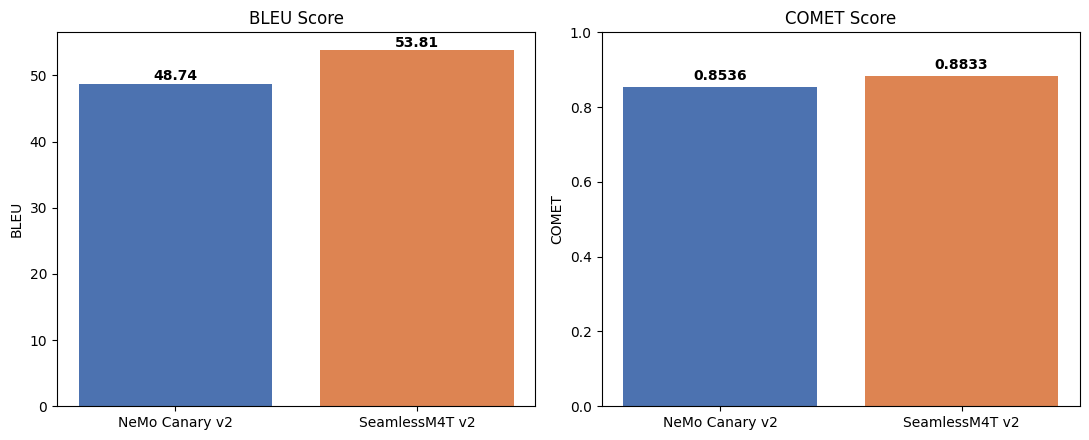

In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

modelos = ['NeMo Canary v2', 'SeamlessM4T v2']
cores = ['#4C72B0', '#DD8452']

# BLEU
axes[0].bar(modelos, [bleu_canary.score, bleu_seamless.score], color=cores)
axes[0].set_title('BLEU Score')
axes[0].set_ylabel('BLEU')
for i, v in enumerate([bleu_canary.score, bleu_seamless.score]):
    axes[0].text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')

# COMET
axes[1].bar(modelos, [resultado_canary.system_score, resultado_seamless.system_score], color=cores)
axes[1].set_title('COMET Score')
axes[1].set_ylabel('COMET')
axes[1].set_ylim(0, 1)
for i, v in enumerate([resultado_canary.system_score, resultado_seamless.system_score]):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig1_bleu_comet_comparacao.png', dpi=150)
plt.show()

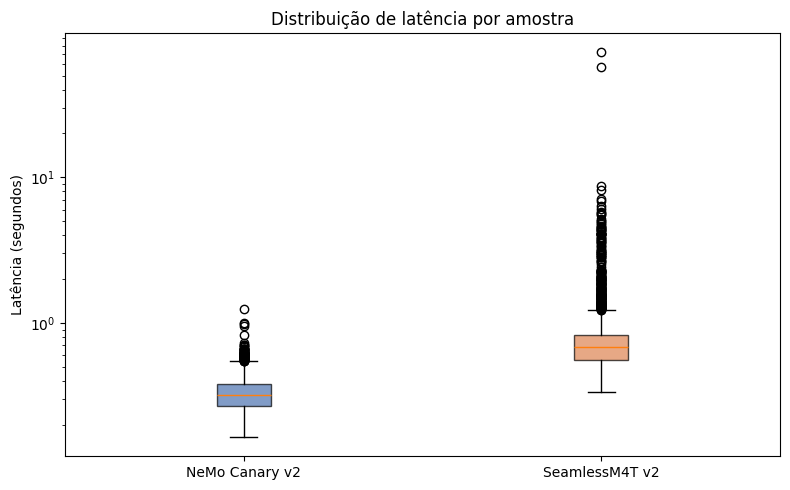

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

dados_latencia = [df_canary['latency_sec'], df_seamless['latency_sec']]
bp = ax.boxplot(dados_latencia, labels=modelos, patch_artist=True, showfliers=True)

for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

ax.set_ylabel('Latência (segundos)')
ax.set_title('Distribuição de latência por amostra')
ax.set_yscale('log')  # escala log por causa do outlier extremo do SeamlessM4T

plt.tight_layout()
plt.savefig('../figures/fig2_latencia_boxplot.png', dpi=150)
plt.show()

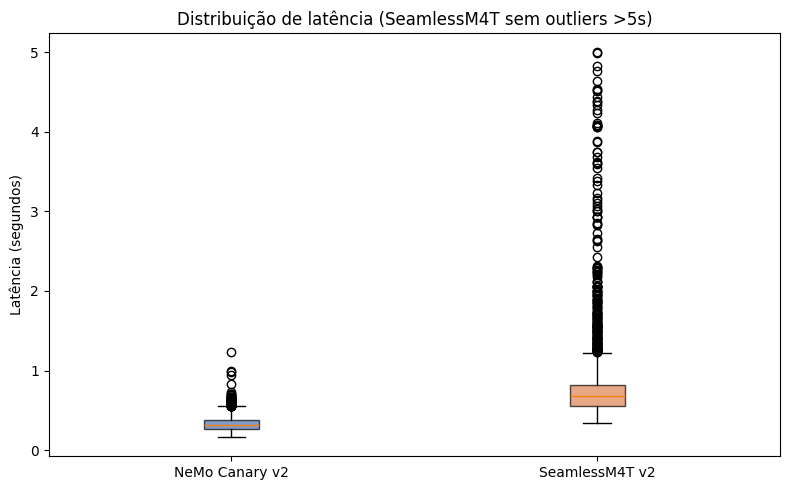

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

canary_clean = df_canary['latency_sec']
seamless_clean = df_seamless[df_seamless['latency_sec'] < 5]['latency_sec']

dados_clean = [canary_clean, seamless_clean]
bp = ax.boxplot(dados_clean, labels=modelos, patch_artist=True)

for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

ax.set_ylabel('Latência (segundos)')
ax.set_title('Distribuição de latência (SeamlessM4T sem outliers >5s)')

plt.tight_layout()
plt.savefig('../figures/fig3_latencia_sem_outliers.png', dpi=150)
plt.show()

In [23]:
resumo = f"""
RESUMO DA COMPARAÇÃO — NeMo Canary v2 vs SeamlessM4T v2
Dataset: CoVoST2 (pt→en), split de teste, {len(df_canary)} amostras

BLEU:
  NeMo Canary v2:   {bleu_canary.score:.2f}
  SeamlessM4T v2:    {bleu_seamless.score:.2f}

COMET:
  NeMo Canary v2:   {resultado_canary.system_score:.4f}
  SeamlessM4T v2:    {resultado_seamless.system_score:.4f}

Latência (segundos):
  NeMo Canary v2:    média={df_canary['latency_sec'].mean():.3f}, mediana={df_canary['latency_sec'].median():.3f}
  SeamlessM4T v2:     média={df_seamless['latency_sec'].mean():.3f}, mediana={df_seamless['latency_sec'].median():.3f}
  
Outliers SeamlessM4T (latência > 5s): {(df_seamless['latency_sec'] > 5).sum()} de {len(df_seamless)} amostras

NOTA METODOLÓGICA: NeMo Canary rodou em GPU NVIDIA T4 (Google Colab).
SeamlessM4T rodou em GPU NVIDIA RTX 3050 6GB Laptop (ambiente local).
A diferença de hardware é uma variável de confusão na comparação de latência.
"""

print(resumo)
with open('../results/resumo_comparacao.txt', 'w', encoding='utf-8') as f:
    f.write(resumo)


RESUMO DA COMPARAÇÃO — NeMo Canary v2 vs SeamlessM4T v2
Dataset: CoVoST2 (pt→en), split de teste, 4023 amostras

BLEU:
  NeMo Canary v2:   48.74
  SeamlessM4T v2:    53.81

COMET:
  NeMo Canary v2:   0.8536
  SeamlessM4T v2:    0.8833

Latência (segundos):
  NeMo Canary v2:    média=0.334, mediana=0.321
  SeamlessM4T v2:     média=0.804, mediana=0.683
  
Outliers SeamlessM4T (latência > 5s): 13 de 4023 amostras

NOTA METODOLÓGICA: NeMo Canary rodou em GPU NVIDIA T4 (Google Colab).
SeamlessM4T rodou em GPU NVIDIA RTX 3050 6GB Laptop (ambiente local).
A diferença de hardware é uma variável de confusão na comparação de latência.

